In [175]:
from IPython.display import Image, display

display(Image(url="https://www.niddk.nih.gov/-/media/Images/Health-Information/Endocrine-Diseases/ThyroidAnatomy_758x864.jpg"))


In [176]:
# Importing Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings("ignore")

In [177]:
#Creating DataFrame
df = pd.read_csv('thyroidDataset.csv')
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,target,patient_id
0,29,F,f,f,f,f,f,f,f,t,f,f,f,f,f,f,t,0.3,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,t,1.6,t,1.9,t,128.0,f,NaN,f,NaN,f,NaN,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,t,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,11.0,other,-,840801042
3,36,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,26.0,other,-,840803046
4,32,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,f,NaN,f,NaN,f,NaN,f,NaN,f,NaN,t,36.0,other,S,840803047


In [178]:
pd.set_option('display.max_columns', None)

# Data Summary

In [179]:
# Total number of rows and columns
row, columns = df.shape
print(f'Total number of rows is: {row}')
print(f'Total number of columns is : {columns}')

Total number of rows is: 9172
Total number of columns is : 31


In [180]:
# Total number of duplicate rows
df.duplicated().sum()

0

In [181]:
# Total number of missing values in each column
df.isna().sum()

age                       0
sex                     307
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
thyroid_surgery           0
I131_treatment            0
query_hypothyroid         0
query_hyperthyroid        0
lithium                   0
goitre                    0
tumor                     0
hypopituitary             0
psych                     0
TSH_measured              0
TSH                     842
T3_measured               0
T3                     2604
TT4_measured              0
TT4                     442
T4U_measured              0
T4U                     809
FTI_measured              0
FTI                     802
TBG_measured              0
TBG                    8823
referral_source           0
target                    0
patient_id                0
dtype: int64

The dataset comprises 9,172 rows and 31 columns, with no duplicate entries. However, there are substantial missing values in the following columns: Sex, TSH, T3, TT4, T4U, FTI, and TBG.

# Data Inspection


In [182]:
# Unique values in 'sex' column
df['sex'].unique()

array(['F', 'M', nan], dtype=object)

In [183]:
#  Counts the frequency of each unique value in the 'sex' column
df['sex'].value_counts()

F    6073
M    2792
Name: sex, dtype: int64

In [184]:
# Unique values in 'TSH_measured' column
df['TSH_measured'].unique()

array(['t', 'f'], dtype=object)

In [185]:
# Filters the 'TSH' column for rows where 'TSH_measured' is 'f' and extracts unique values
df['TSH'][df['TSH_measured'] == 'f'].unique()

array([nan])

In [186]:
# Counts the number of missing TSH values for patients where TSH was not measured
df['TSH'][df['TSH_measured'] == 'f'].isnull().sum()

842

In [187]:
# Count of missing values in TSH
df['TSH'].isnull().sum()

842

It is evident from the analysis that null values in the 'TSH' column occur exclusively when the 'TSH_measured' column contains 'f'. This indicates that for patients whose TSH levels were not tested in the blood, there will be no corresponding test scores recorded.

In [188]:
# Unique values in 'T3_measured' column
df['T3_measured'].unique()

array(['f', 't'], dtype=object)

In [189]:
# Filters the 'T3' column for rows where 'T3_measured' is 'f' and extracts unique values
df['T3'][df['T3_measured'] == 'f'].unique()

array([nan])

In [190]:
# Counts the number of missing T3 values for patients where T3 was not measured
df['T3'][df['T3_measured'] == 'f'].isnull().sum()

2604

In [191]:
# Count of missing values in T3
df['T3'].isnull().sum()

2604

It is evident from the analysis that null values in the 'T3' column occur exclusively when the 'T3_measured' column contains 'f'. This indicates that for patients whose T3 levels were not tested in the blood, there will be no corresponding test scores recorded.

In [192]:
# Unique values in 'TT4_measured' column
df['TT4_measured'].unique()

array(['f', 't'], dtype=object)

In [193]:
# Filters the 'TT4' column for rows where 'TT4_measured' is 'f' and extracts unique values
df['TT4'][df['TT4_measured'] == 'f'].unique()

array([nan])

In [194]:
# Counts the number of missing TT4 values for patients where TT4 was not measured
df['TT4'][df['TT4_measured'] == 'f'].isnull().sum()

442

In [195]:
# Count of missing values in TT4
df['TT4'].isnull().sum()

442

It is evident from the analysis that null values in the 'TT4' column occur exclusively when the 'TT4_measured' column contains 'f'. This indicates that for patients whose TT4 levels were not tested in the blood, there will be no corresponding test scores recorded.

In [196]:
# Unique values in 'T4U_measured' column
df['T4U_measured'].unique()

array(['f', 't'], dtype=object)

In [197]:
# Filters the 'T4U' column for rows where 'T4U_measured' is 'f' and extracts unique values
df['T4U'][df['T4U_measured'] == 'f'].unique()

array([nan])

In [198]:
# Counts the number of missing T4U values for patients where T4U was not measured
df['T4U'][df['T4U_measured'] == 'f'].isnull().sum()

809

In [199]:
# Count of missing values in T4U
df['T4U'].isnull().sum()

809

It is evident from the analysis that null values in the 'T4U' column occur exclusively when the 'T4U_measured' column contains 'f'. This indicates that for patients whose T4U levels were not tested in the blood, there will be no corresponding test scores recorded.

In [200]:
# Unique values in 'FTI_measured' column
df['FTI_measured'].unique()

array(['f', 't'], dtype=object)

In [201]:
# Filters the 'FTI' column for rows where 'FTI_measured' is 'f' and extracts unique values
df['FTI'][df['FTI_measured'] == 'f'].unique()

array([nan])

In [202]:
# Counts the number of missing FTI values for patients where FTI was not measured
df['FTI'][df['FTI_measured'] == 'f'].isnull().sum()

802

In [203]:
# Count of missing values in FTI
df['FTI'].isnull().sum()

802


It is evident from the analysis that null values in the 'FTI' column occur exclusively when the 'FTI_measured' column contains 'f'. This indicates that for patients whose FTI levels were not tested in the blood, there will be no corresponding test scores recorded.

In [204]:
# Unique values in 'TBG_measured' column
df['TBG_measured'].unique()

array(['f', 't'], dtype=object)

In [205]:
# Filters the 'TBG' column for rows where 'TBG_measured' is 'f' and extracts unique values
df['TBG'][df['TBG_measured'] == 'f'].unique()

array([nan])

In [206]:
# Counts the number of missing TBG values for patients where TBG was not measured
df['TBG'][df['TBG_measured'] == 'f'].isnull().sum()

8823

In [207]:
# Count of missing values in TBG
df['TBG'].isnull().sum()

8823

It is evident from the analysis that null values in the 'TBG' column occur exclusively when the 'TBG_measured' column contains 'f'. This indicates that for patients whose TBG levels were not tested in the blood, there will be no corresponding test scores recorded.

**Conclusion:** 

The analysis clearly demonstrates that the presence of null values in the TSH, T3, TT4, T4U, FTI, and TBG columns is directly associated with the corresponding TSH_measured, T3_measured, TT4_measured, T4U_measured, FTI_measured, and TBG_measured columns containing the value 'f'. This indicates that for patients whose TSH, T3, TT4, T4U, FTI, and TBG levels were not measured during blood testing, no test results were recorded for these parameters.

# Feature Engineering

In [208]:
# Unique classes in 'target' column
df['target'].unique()

array(['-', 'S', 'F', 'AK', 'R', 'I', 'M', 'N', 'G', 'K', 'A', 'KJ', 'L',
       'MK', 'Q', 'J', 'C|I', 'O', 'LJ', 'H|K', 'D', 'GK', 'MI', 'P',
       'FK', 'B', 'GI', 'C', 'GKJ', 'OI', 'D|R', 'E'], dtype=object)

**Diagnosis**

1. Hyperthyroid (A), T3 toxic (B), Toxic goitre (C), and Secondary toxic (D) are different Hyperthyroid conditions.

2. Hypothyroid (E), Primary Hypothyroid (F), Compensated Hypothyroid (G), and Secondary Hypothyroid (H) are different Hypothyroid conditions. 

3. "-" indicates no Thyroid conditions.

4. All Anti-thyroid treatments listed in this dataset, such as Antithyroid drugs (O), I131 treatment (P) and Surgery (Q) are recommended in case of Hyperthyroid Disorders.

5. Elevated thyroid hormones (T), also known as hyperthyroidism, occurs when the thyroid gland produces too many thyroid hormones.
 
6. Elevated Thyroxine-Binding Globulin (TBG) (S) is directly assocaited with Hyperthyroidism. 

In [209]:
# Categorizing different classes into 3 major thyroid conditions: Hyperthyroid, Hypothyroid and Negative (No Thyroid Condition)
hyperthyroid_conditions = ['A', 'B', 'C', 'D', 'O', 'P', 'Q', 'S', 'T']
hypothyroid_conditions = ['E', 'F', 'G', 'H']
normal_conditions = ['-']

def categorize_target(value):
    # Split the diagnosis into parts for compound cases
    diagnoses = value.split('|')
    # Check for hyperthyroid conditions
    for diagnosis in diagnoses:
        if diagnosis in hyperthyroid_conditions:
            return 'Hyperthyroid'
    # Check for hypothyroid conditions
    for diagnosis in diagnoses:
        if diagnosis in hypothyroid_conditions:
            return 'Hypothyroid'
            
    for diagnosis in diagnoses:
        if diagnosis in normal_conditions:
            return 'Negative'

#Applying 'categorize_target' function on 'target' column to categorize the values into 3 classes
df['target'] = df['target'].apply(categorize_target)

In [210]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
       'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
       'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source',
       'target', 'patient_id'],
      dtype='object')

In [211]:
#Unique Classes in 'target' column
df['target'].unique()

array(['Negative', 'Hyperthyroid', 'Hypothyroid', None], dtype=object)

In [212]:
#  Counts the frequency of each unique classes in the 'target' column
df['target'].value_counts()

Negative        6771
Hypothyroid      601
Hyperthyroid     313
Name: target, dtype: int64

In [213]:
# Count the missing values in 'target' column
df['target'].isnull().sum()

1487

## Data Cleaning
To address these missing values, appropriate imputation methods will be applied:

1. Missing values in the Sex column will be imputed using the mode of that column.
2. Missing values in TSH, T3, TT4, T4U, and FTI will be filled with the median of the respective columns.
3. Due to an excessive amount of missing values in the TBG column, it will be dropped to prevent any potential inconsistencies.

In [214]:
# Imputing the missing values in 'sex' column with mode of the column
sex_mode = df['sex'].mode()[0]
sex_mode

'F'

In [215]:
# Imputing the missing values in 'sex' column with its mode
df['sex'] = df['sex'].fillna(sex_mode)
df['sex'].isna().sum()

0

In [216]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
       'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
       'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source',
       'target', 'patient_id'],
      dtype='object')

In [217]:
# List of columns that will be dropped
col_to_drop = ['TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured', 'patient_id']

In [218]:
# Dropping the columns in the 'col_to_drop' list
df.drop(col_to_drop, axis = 1, inplace = True)

In [219]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_meds', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U',
       'FTI', 'TBG', 'referral_source', 'target'],
      dtype='object')

In [220]:
# List of columns containing missing values
col_with_null = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']

In [221]:
# Imputing the missing values in columns, in 'col_with_null' list, with 0
for col in col_with_null:
    df[col] = df[col].fillna(0)

In [222]:
# Count of missing values in each column
df.isnull().sum()

age                       0
sex                       0
on_thyroxine              0
query_on_thyroxine        0
on_antithyroid_meds       0
sick                      0
pregnant                  0
thyroid_surgery           0
I131_treatment            0
query_hypothyroid         0
query_hyperthyroid        0
lithium                   0
goitre                    0
tumor                     0
hypopituitary             0
psych                     0
TSH                       0
T3                        0
TT4                       0
T4U                       0
FTI                       0
TBG                       0
referral_source           0
target                 1487
dtype: int64

In [223]:
# Dropping the missing values
df.dropna(inplace=True)

In [224]:
# Count of missing values in each column
df.isnull().sum()

age                    0
sex                    0
on_thyroxine           0
query_on_thyroxine     0
on_antithyroid_meds    0
sick                   0
pregnant               0
thyroid_surgery        0
I131_treatment         0
query_hypothyroid      0
query_hyperthyroid     0
lithium                0
goitre                 0
tumor                  0
hypopituitary          0
psych                  0
TSH                    0
T3                     0
TT4                    0
T4U                    0
FTI                    0
TBG                    0
referral_source        0
target                 0
dtype: int64

In [225]:
df

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
0,29,F,f,f,f,f,f,f,f,t,f,f,f,f,f,f,0.3,0.0,0.0,0.00,0.0,0.0,other,Negative
1,29,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,1.6,1.9,128.0,0.00,0.0,0.0,other,Negative
2,41,F,f,f,f,f,f,f,f,f,t,f,f,f,f,f,0.0,0.0,0.0,0.00,0.0,11.0,other,Negative
3,36,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,0.0,0.00,0.0,26.0,other,Negative
4,32,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,0.0,0.00,0.0,36.0,other,Hyperthyroid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9166,70,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,88.0,0.74,119.0,0.0,SVI,Negative
9167,56,M,f,f,f,f,f,f,f,f,t,f,f,f,f,f,0.0,0.0,64.0,0.83,77.0,0.0,SVI,Negative
9168,22,M,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,91.0,0.92,99.0,0.0,SVI,Negative
9170,47,F,f,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,75.0,0.85,88.0,0.0,other,Negative


In [226]:
# Unique values in the columns with 'object' data type'
for i in df.columns:
    if df[i].dtype == 'object':
        print(f'Unique values in {i}: {df[i].unique()}')

Unique values in sex: ['F' 'M']
Unique values in on_thyroxine: ['f' 't']
Unique values in query_on_thyroxine: ['f' 't']
Unique values in on_antithyroid_meds: ['f' 't']
Unique values in sick: ['f' 't']
Unique values in pregnant: ['f' 't']
Unique values in thyroid_surgery: ['f' 't']
Unique values in I131_treatment: ['f' 't']
Unique values in query_hypothyroid: ['t' 'f']
Unique values in query_hyperthyroid: ['f' 't']
Unique values in lithium: ['f' 't']
Unique values in goitre: ['f' 't']
Unique values in tumor: ['f' 't']
Unique values in hypopituitary: ['f']
Unique values in psych: ['f' 't']
Unique values in referral_source: ['other' 'SVI' 'SVHC' 'STMW' 'SVHD' 'WEST']
Unique values in target: ['Negative' 'Hyperthyroid' 'Hypothyroid']


In [227]:
#Shape of df
df.shape

(7685, 24)

Since the 'hypopituitary' column contains only a single unique value, it is unlikely to contribute to pattern recognition or enhance the performance of a data model.

In [228]:
# Dropping 'hypopituitary' column
df.drop('hypopituitary', axis = 1, inplace = True)

In [229]:
df.shape

(7685, 23)

In [230]:
#Unique values in 'age' column
df['age'].unique()

array([   29,    41,    36,    32,    60,    77,    28,    54,    42,
          51,    37,    16,    43,    63,    40,    56,    85,    67,
          61,    46,    44,    82,    64,    70,    33,    53,    52,
          59,    49,    35,    48,    27,    69,    76,    73,    68,
          66,    30,    58,    21,    38,    45,    62,    25,    86,
          83,    75,    72,    55,    14,    15,    39,    20,    80,
          90,    23,    13,    78,    24,    71,    81,    92,    57,
          74,     9,    47,    17,    11,    50,    26,    34,     8,
          79,    31,    65,    84,    12,    10,    88,    18,     1,
          22,     2,    97,     6,    19,    89,    87,   455,    91,
          94,     7, 65511,     4, 65512,     3,    93, 65526,     5,
          95], dtype=int64)

There are some discrepencies in the 'age' column. It is containing values like 455, 65511, 65512, and 65526.

In [231]:
# Filtering the values in 'age' column
df = df[df['age'] <= 100]

# Unique values in 'age' column
df['age'].unique()

array([29, 41, 36, 32, 60, 77, 28, 54, 42, 51, 37, 16, 43, 63, 40, 56, 85,
       67, 61, 46, 44, 82, 64, 70, 33, 53, 52, 59, 49, 35, 48, 27, 69, 76,
       73, 68, 66, 30, 58, 21, 38, 45, 62, 25, 86, 83, 75, 72, 55, 14, 15,
       39, 20, 80, 90, 23, 13, 78, 24, 71, 81, 92, 57, 74,  9, 47, 17, 11,
       50, 26, 34,  8, 79, 31, 65, 84, 12, 10, 88, 18,  1, 22,  2, 97,  6,
       19, 89, 87, 91, 94,  7,  4,  3, 93,  5, 95], dtype=int64)

In [232]:
df.shape

(7681, 23)

In [233]:
# Checking whether data has any anomalies where patient is male but have 'true' in 'pregnant' column
df[(df['sex']=='Male') & (df['pregnant'] == 't')]

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target


There are no instances in the dataset where a "Male" is marked as "pregnant." This is a logical result and validates the integrity of the data for this specific condition. In such cases, we can infer that:

* The dataset does not contain biologically implausible entries for this scenario.
* The data aligns with expected real-world constraints (assuming there are no labeling or data entry errors).

In [234]:
# Creating a copy of 'df' without any null values for data visualization
df1 = df.copy()

## Data Encoding

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7681 entries, 0 to 9171
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  7681 non-null   int64  
 1   sex                  7681 non-null   object 
 2   on_thyroxine         7681 non-null   object 
 3   query_on_thyroxine   7681 non-null   object 
 4   on_antithyroid_meds  7681 non-null   object 
 5   sick                 7681 non-null   object 
 6   pregnant             7681 non-null   object 
 7   thyroid_surgery      7681 non-null   object 
 8   I131_treatment       7681 non-null   object 
 9   query_hypothyroid    7681 non-null   object 
 10  query_hyperthyroid   7681 non-null   object 
 11  lithium              7681 non-null   object 
 12  goitre               7681 non-null   object 
 13  tumor                7681 non-null   object 
 14  psych                7681 non-null   object 
 15  TSH                  7681 non-null   f

In [236]:
# Unique values in the columns with 'object' data type' and appending the column names in the list 'obj_col'
obj_col = []
for i in df.columns:
    if df[i].dtype == 'object':
        print(f'Unique values in {i}: {df[i].unique()}')
        obj_col.append(i)

Unique values in sex: ['F' 'M']
Unique values in on_thyroxine: ['f' 't']
Unique values in query_on_thyroxine: ['f' 't']
Unique values in on_antithyroid_meds: ['f' 't']
Unique values in sick: ['f' 't']
Unique values in pregnant: ['f' 't']
Unique values in thyroid_surgery: ['f' 't']
Unique values in I131_treatment: ['f' 't']
Unique values in query_hypothyroid: ['t' 'f']
Unique values in query_hyperthyroid: ['f' 't']
Unique values in lithium: ['f' 't']
Unique values in goitre: ['f' 't']
Unique values in tumor: ['f' 't']
Unique values in psych: ['f' 't']
Unique values in referral_source: ['other' 'SVI' 'SVHC' 'STMW' 'SVHD' 'WEST']
Unique values in target: ['Negative' 'Hyperthyroid' 'Hypothyroid']


In [237]:
obj_col

['sex',
 'on_thyroxine',
 'query_on_thyroxine',
 'on_antithyroid_meds',
 'sick',
 'pregnant',
 'thyroid_surgery',
 'I131_treatment',
 'query_hypothyroid',
 'query_hyperthyroid',
 'lithium',
 'goitre',
 'tumor',
 'psych',
 'referral_source',
 'target']

In [238]:
# Creating an object for Label Encoder Class
le = LabelEncoder()

In [239]:
# Create mappings for categorical variables
sex_map = {'F':0, 'M':1}
obj_col_map = {'f':0, 't':1}

In [240]:
# Apply 'sex_map' on 'sex' column
df['sex'] = df['sex'].map(sex_map)

In [241]:
# Label Encoding the 'referral_source' column
df['referral_source'] = le.fit_transform(df['referral_source'])

In [242]:
# Apply 'obj_col_map' on columns with 'object' data type, except the 'target' column
for i in df.columns:
    if df[i].dtype == 'object' and i != 'target':
        df[i] = df[i].map(obj_col_map)

In [243]:
for i in obj_col:
        print(f'Unique values in {i}: {df[i].unique()}')

Unique values in sex: [0 1]
Unique values in on_thyroxine: [0 1]
Unique values in query_on_thyroxine: [0 1]
Unique values in on_antithyroid_meds: [0 1]
Unique values in sick: [0 1]
Unique values in pregnant: [0 1]
Unique values in thyroid_surgery: [0 1]
Unique values in I131_treatment: [0 1]
Unique values in query_hypothyroid: [1 0]
Unique values in query_hyperthyroid: [0 1]
Unique values in lithium: [0 1]
Unique values in goitre: [0 1]
Unique values in tumor: [0 1]
Unique values in psych: [0 1]
Unique values in referral_source: [5 3 1 0 2 4]
Unique values in target: ['Negative' 'Hyperthyroid' 'Hypothyroid']


In [244]:
df

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
0,29,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0.3,0.0,0.0,0.00,0.0,0.0,5,Negative
1,29,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.6,1.9,128.0,0.00,0.0,0.0,5,Negative
2,41,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.0,0.0,0.0,0.00,0.0,11.0,5,Negative
3,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.00,0.0,26.0,5,Negative
4,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.00,0.0,36.0,5,Hyperthyroid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9166,70,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,88.0,0.74,119.0,0.0,3,Negative
9167,56,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0.0,0.0,64.0,0.83,77.0,0.0,3,Negative
9168,22,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,91.0,0.92,99.0,0.0,3,Negative
9170,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,75.0,0.85,88.0,0.0,5,Negative


# Data Visualization

In [245]:
# Create a dictionary to map gender codes to proper gender categories
gender_map = {'F': 'Female', 'M':'Male'}
df1['sex'] = df1['sex'].map(gender_map)
df1

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source,target
0,29,Female,f,f,f,f,f,f,f,t,f,f,f,f,f,0.3,0.0,0.0,0.00,0.0,0.0,other,Negative
1,29,Female,f,f,f,f,f,f,f,f,f,f,f,f,f,1.6,1.9,128.0,0.00,0.0,0.0,other,Negative
2,41,Female,f,f,f,f,f,f,f,f,t,f,f,f,f,0.0,0.0,0.0,0.00,0.0,11.0,other,Negative
3,36,Female,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,0.0,0.00,0.0,26.0,other,Negative
4,32,Female,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,0.0,0.00,0.0,36.0,other,Hyperthyroid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9166,70,Female,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,88.0,0.74,119.0,0.0,SVI,Negative
9167,56,Male,f,f,f,f,f,f,f,f,t,f,f,f,f,0.0,0.0,64.0,0.83,77.0,0.0,SVI,Negative
9168,22,Male,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,91.0,0.92,99.0,0.0,SVI,Negative
9170,47,Female,f,f,f,f,f,f,f,f,f,f,f,f,f,0.0,0.0,75.0,0.85,88.0,0.0,other,Negative


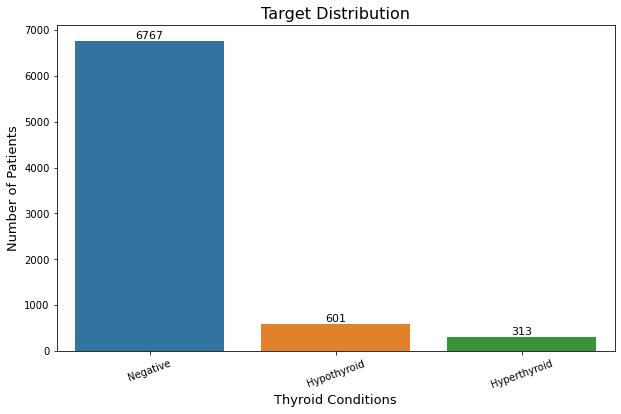

In [246]:
# ============================================
# TARGET DISTRIBUTION PLOT
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Count target values
target_df = (
    df1['target']
    .value_counts()
    .reset_index()
)

# Rename columns
target_df.columns = ['target', 'count']

# Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=target_df,
    x='target',
    y='count'
)

# Add labels
for p in ax.patches:

    height = p.get_height()

    # Skip NaN heights
    if not np.isnan(height):

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=11
        )

# Titles
plt.title('Target Distribution', fontsize=16)
plt.xlabel('Thyroid Conditions', fontsize=13)
plt.ylabel('Number of Patients', fontsize=13)

plt.xticks(rotation=20)

plt.show()

**Class Distribution**

**1. Negative Cases (6767):** <br>
* A vast majority (around 85.4%) of individuals in the dataset are classified as "Negative," meaning they do not have any thyroid condition.
* This dominance indicates a substantial class imbalance in the dataset, which is typical in medical datasets due to the relative rarity of diseases compared to healthy cases.
<br>

**2. Hypothyroid Cases (601):**
* Approximately 7.3% of individuals have been diagnosed with hypothyroidism.
* This is the second-largest class, suggesting that hypothyroidism is a relatively common thyroid condition compared to hyperthyroidism.
<br>

**3. Hyperthyroid Cases (313):** <br>
* Only about 3.9% of individuals have hyperthyroidism, making it the smallest group.
* This indicates that hyperthyroidism is less prevalent than hypothyroidism in this dataset.
<br>
<br>

**Imbalance Between Conditions:** <br>
1. The ratio of "Negative" cases to both "Hypothyroid" and "Hyperthyroid" cases highlights a significant imbalance.
2. Specifically:
    * For every hypothyroid case, there are roughly 11.3 negative cases.
    * For every hyperthyroid case, there are approximately 21.6 negative cases.

['Female' 'Male']


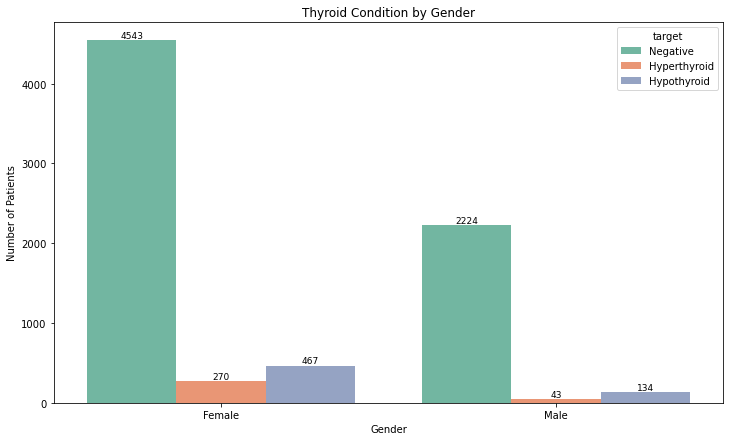

In [247]:
df1 = df.copy()

df1['sex'] = df1['sex'].map({
    0: 'Female',
    1: 'Male'
})

print(df1['sex'].unique())

plot_df = df1.dropna(subset=['sex', 'target'])

# Convert to string
plot_df['sex'] = plot_df['sex'].astype(str)

plt.figure(figsize=(12,7))

ax = sns.countplot(
    data=plot_df,
    x='sex',
    hue='target',
    palette='Set2'
)

# Add labels
for p in ax.patches:

    height = p.get_height()

    if height > 0:

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# Labels
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.title('Thyroid Condition by Gender')

plt.show()

**Insights:**

The prevalence of hyperthyroidism and hypothyroidism is higher in females compared to males, indicating that females are more likely to develop thyroid conditions.

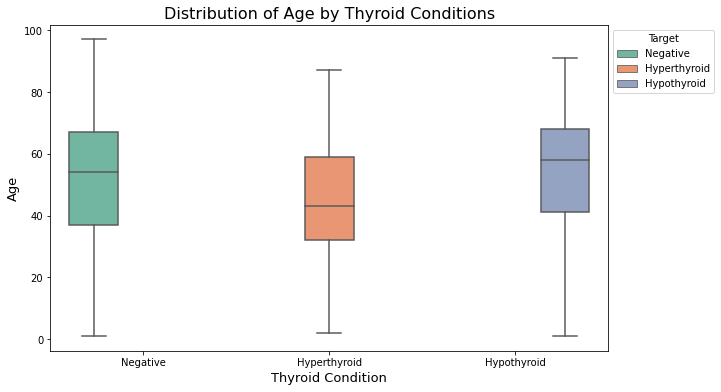

In [248]:

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df1,
    x='target',
    y='age',
    hue='target',
    palette='Set2'
)

plt.title('Distribution of Age by Thyroid Conditions', fontsize=16)
plt.xlabel('Thyroid Condition', fontsize=13)
plt.ylabel('Age', fontsize=13)

plt.legend(
    loc='best',
    frameon=True,
    title='Target',
    bbox_to_anchor=(1,1)
)

plt.show()

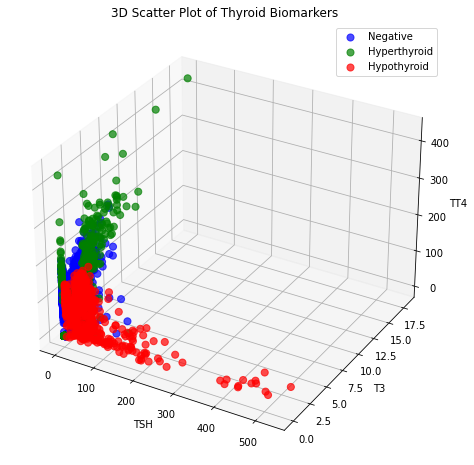

In [249]:
from mpl_toolkits.mplot3d import Axes3D

# Create figure
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

# Encode target labels for colors
colors = {
    'Negative':'blue',
    'Hypothyroid':'red',
    'Hyperthyroid':'green'
}

# Plot each class separately
for condition in df1['target'].unique():

    subset = df1[df1['target'] == condition]

    ax.scatter(
        subset['TSH'],
        subset['T3'],
        subset['TT4'],
        c=colors[condition],
        label=condition,
        s=50,
        alpha=0.7
    )

# Labels
ax.set_xlabel('TSH')
ax.set_ylabel('T3')
ax.set_zlabel('TT4')

plt.title('3D Scatter Plot of Thyroid Biomarkers')
plt.legend()
plt.show()

### Insights

1. Distinct clustering patterns can be observed among Negative, Hypothyroid, and Hyperthyroid patients based on thyroid biomarkers.

2. Hyperthyroid patients tend to exhibit lower TSH values with relatively elevated T3 and TT4 levels.

3. Hypothyroid patients generally show higher TSH values and lower thyroid hormone concentrations.

4. Negative cases are densely concentrated around normal biomarker ranges, forming the largest cluster.

5. The separation between classes indicates that TSH, T3, and TT4 are highly influential features for thyroid disorder classification.

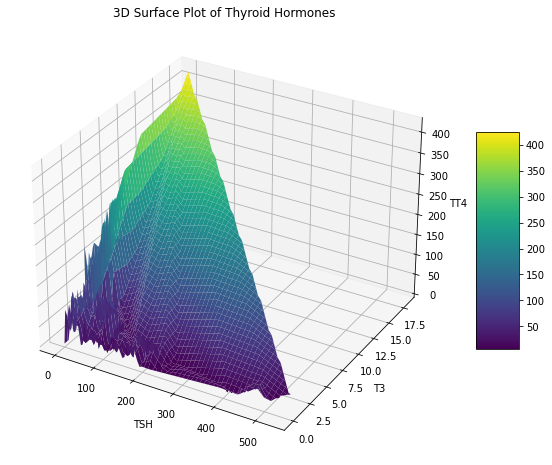

In [250]:
from scipy.interpolate import griddata

# Remove missing values
surface_df = df1[['TSH','T3','TT4']].dropna()

x = surface_df['TSH']
y = surface_df['T3']
z = surface_df['TT4']

# Create grid
xi = np.linspace(x.min(), x.max(), 100)
yi = np.linspace(y.min(), y.max(), 100)

X, Y = np.meshgrid(xi, yi)

# Interpolate
Z = griddata((x, y), z, (X, Y), method='linear')

# Plot
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap='viridis',
    edgecolor='none'
)

ax.set_xlabel('TSH')
ax.set_ylabel('T3')
ax.set_zlabel('TT4')

plt.title('3D Surface Plot of Thyroid Hormones')
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

### Insights

1. The surface plot demonstrates the nonlinear relationship among TSH, T3, and TT4.

2. Variations in TT4 levels are strongly influenced by changes in TSH and T3 concentrations.

3. Irregular surface regions indicate complex hormonal interactions commonly observed in thyroid dysfunction.

4. The nonlinear patterns justify the use of advanced machine learning models such as Random Forest, XGBoost, and CatBoost.

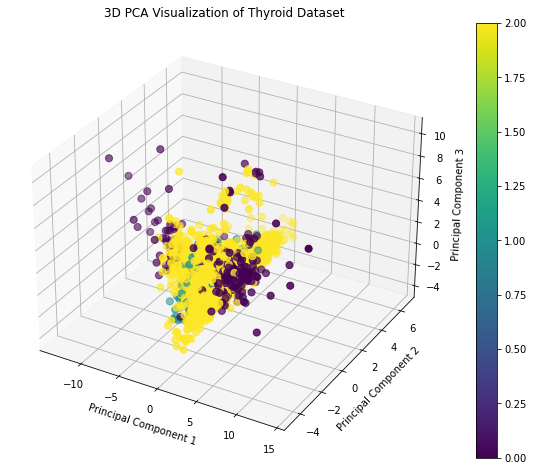

In [251]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

# Copy dataframe
pca_df = df1.copy()

# Encode categorical columns
for col in pca_df.columns:

    if pca_df[col].dtype == 'object':

        le = LabelEncoder()
        pca_df[col] = le.fit_transform(pca_df[col].astype(str))

# Features and target
X = pca_df.drop('target', axis=1)
y = pca_df['target']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Plot
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=y,
    cmap='viridis',
    s=50
)

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

plt.title('3D PCA Visualization of Thyroid Dataset')
plt.colorbar(scatter)
plt.show()

In [252]:
import plotly.express as px

# Remove missing values
plot_df = df1[['TSH', 'T3', 'TT4', 'target']].dropna()

# Interactive plot
fig = px.scatter_3d(
    plot_df,
    x='TSH',
    y='T3',
    z='TT4',
    color='target',
    opacity=0.7,
    title='Interactive 3D Thyroid Biomarker Visualization'
)

# Customize layout
fig.update_layout(
    width=1000,
    height=700
)

fig.show()

In [253]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import plotly.express as px

# Create copy
pca_df = df1.copy()

# Encode categorical columns
for col in pca_df.columns:

    if pca_df[col].dtype == 'object':

        le = LabelEncoder()
        pca_df[col] = le.fit_transform(
            pca_df[col].astype(str)
        )

# Features and target
X = pca_df.drop('target', axis=1)
y = pca_df['target']

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA transformation
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Create dataframe
pca_plot = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'PC3': X_pca[:,2],
    'target': y
})

# Interactive PCA plot
fig = px.scatter_3d(
    pca_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='target',
    title='Interactive 3D PCA Visualization'
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()

In [254]:
print(df1['query_hypothyroid'].unique())
print(df1['query_hyperthyroid'].unique())

[1 0]
[0 1]


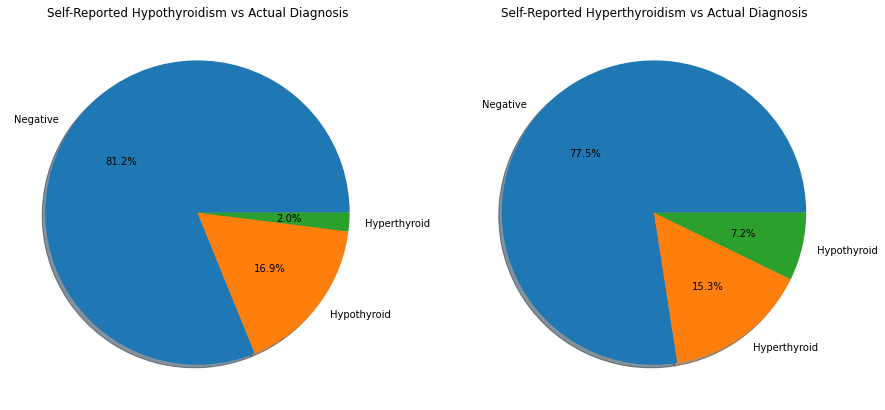

In [255]:
# ============================================
# SELF-REPORTED VS ACTUAL DIAGNOSIS
# ============================================

import matplotlib.pyplot as plt

# Filter encoded values (1 = True)
df_query_hypo = df1[
    df1['query_hypothyroid'] == 1
]

df_query_hypo_counts = (
    df_query_hypo['target']
    .value_counts()
)

df_query_hyper = df1[
    df1['query_hyperthyroid'] == 1
]

df_query_hyper_counts = (
    df_query_hyper['target']
    .value_counts()
)

# ============================================
# PLOTS
# ============================================

plt.figure(figsize=(15,7))

# Hypothyroid
plt.subplot(1,2,1)

plt.pie(
    df_query_hypo_counts,
    labels=df_query_hypo_counts.index,
    autopct='%1.1f%%',
    shadow=True
)

plt.title(
    'Self-Reported Hypothyroidism vs Actual Diagnosis'
)

# Hyperthyroid
plt.subplot(1,2,2)

plt.pie(
    df_query_hyper_counts,
    labels=df_query_hyper_counts.index,
    autopct='%1.1f%%',
    shadow=True
)

plt.title(
    'Self-Reported Hyperthyroidism vs Actual Diagnosis'
)

plt.show()

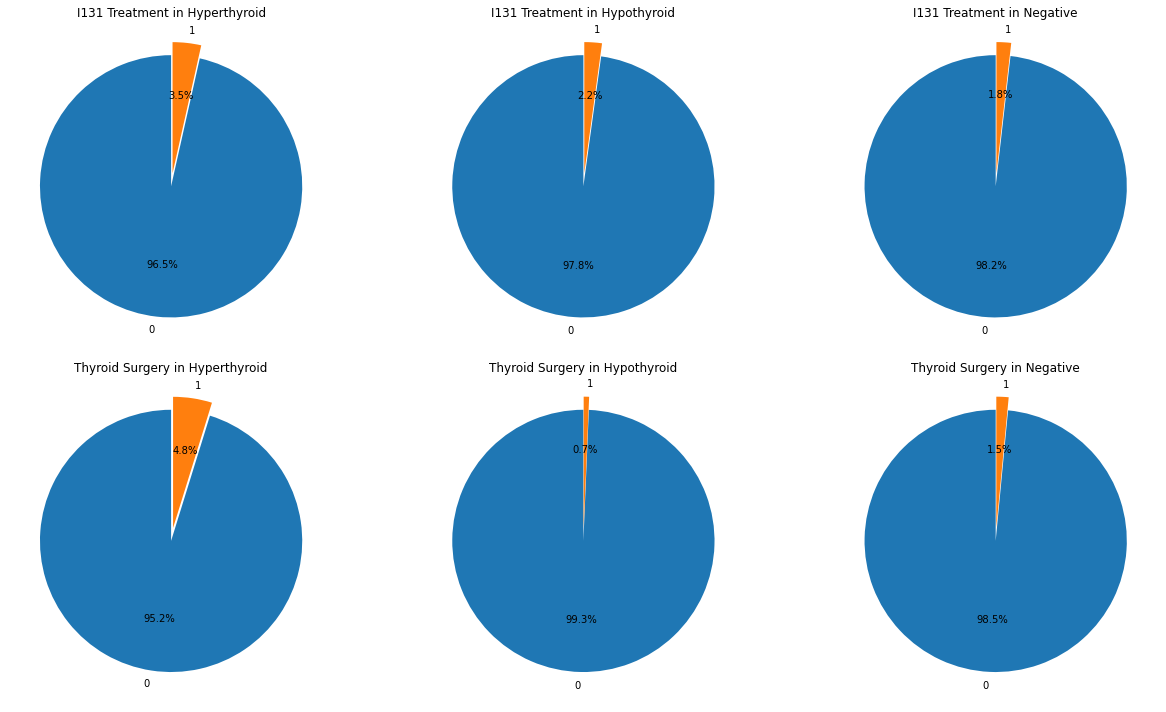

In [256]:
# ============================================
# I131 TREATMENT & THYROID SURGERY ANALYSIS
# ============================================

import matplotlib.pyplot as plt

# Crosstab for I131 treatment
i131_counts = pd.crosstab(
    df1['target'],
    df1['I131_treatment']
)

# Crosstab for surgery
surgery_counts = pd.crosstab(
    df1['target'],
    df1['thyroid_surgery']
)

# Number of target classes
n_targets = len(df1['target'].unique())

# Create subplots
fig, axes = plt.subplots(
    2,
    n_targets,
    figsize=(18,10)
)

# ============================================
# I131 TREATMENT PIE CHARTS
# ============================================

for i, target in enumerate(i131_counts.index):

    values = i131_counts.loc[target]

    explode = [0.1 if v == 1 else 0 for v in values.index]

    axes[0, i].pie(
        values,
        labels=values.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode
    )

    axes[0, i].set_title(
        f'I131 Treatment in {target}'
    )

# ============================================
# THYROID SURGERY PIE CHARTS
# ============================================

for i, target in enumerate(surgery_counts.index):

    values = surgery_counts.loc[target]

    explode = [0.1 if v == 1 else 0 for v in values.index]

    axes[1, i].pie(
        values,
        labels=values.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode
    )

    axes[1, i].set_title(
        f'Thyroid Surgery in {target}'
    )

# Layout
plt.tight_layout()

plt.show()

**Inferences** <br>

* The proportions of individuals receiving I131 treatment and Thyroid Surgery are higher in Hyperthyroid cases compared to Hypothyroid and Negative cases.
* This aligns with the use of I131 treatment and Thyroid Surgery for conditions like Hyperthyroidism.

**Insights** <br>

* Both I131 treatment and thyroid surgery are most prevalent in individuals with Hyperthyroid, reflecting standard treatment practices for severe cases.

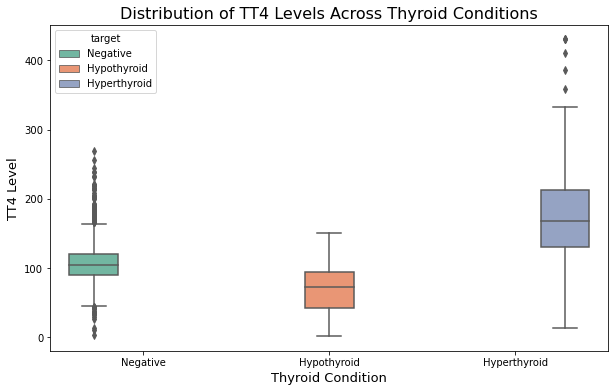

In [257]:
plot_df = df1[df1['TT4'] > 0]

# Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=plot_df,
    x='target',
    y='TT4',
    hue='target',
    palette='Set2'
)

# Titles
plt.title(
    'Distribution of TT4 Levels Across Thyroid Conditions',
    fontsize=16
)

plt.xlabel(
    'Thyroid Condition',
    fontsize=13
)

plt.ylabel(
    'TT4 Level',
    fontsize=13
)

plt.show()

In [258]:
df1['referral_source'].unique()

array([5, 3, 1, 0, 2, 4])

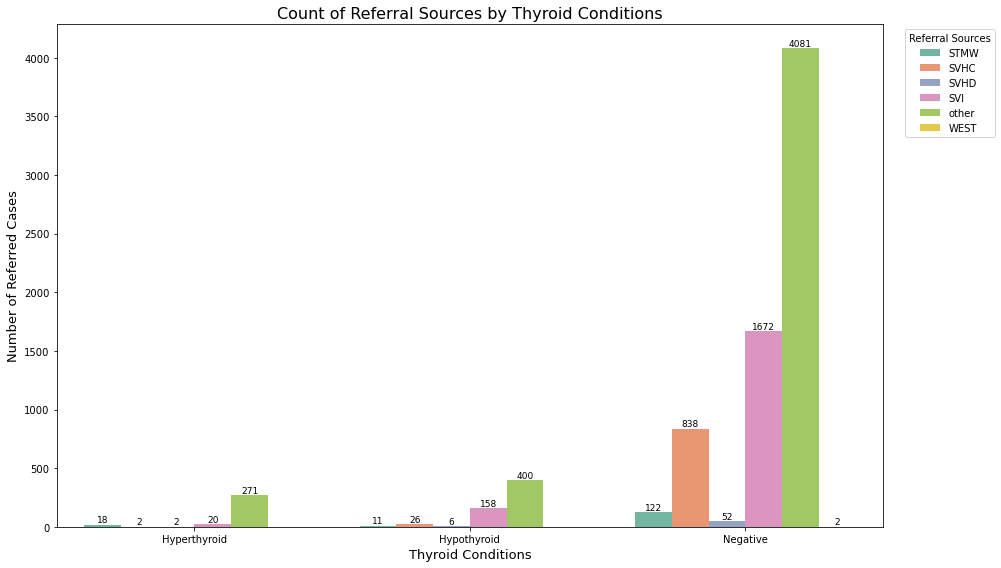

In [259]:
referral_mapping = {
    0: 'STMW',
    1: 'SVHC',
    2: 'SVHD',
    3: 'SVI',
    4: 'WEST',
    5: 'other'
}

# Convert encoded values back
df1['referral_source'] = df1['referral_source'].map(
    referral_mapping
)

# Group counts
count_data = (
    df1.groupby(
        ['target', 'referral_source']
    )
    .size()
    .reset_index(name='Count')
)

# Plot
plt.figure(figsize=(14,8))

ax = sns.barplot(
    data=count_data,
    x='target',
    y='Count',
    hue='referral_source',
    palette='Set2'
)

# Add labels
for p in ax.patches:

    height = p.get_height()

    if not np.isnan(height) and height > 0:

        ax.annotate(
            f'{int(height)}',
            (
                p.get_x() + p.get_width()/2,
                height
            ),
            ha='center',
            va='bottom',
            fontsize=9
        )

# Titles
plt.title(
    'Count of Referral Sources by Thyroid Conditions',
    fontsize=16
)

plt.xlabel(
    'Thyroid Conditions',
    fontsize=13
)

plt.ylabel(
    'Number of Referred Cases',
    fontsize=13
)

plt.legend(
    title='Referral Sources',
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

# Data Split

In [260]:
# Splits the DataFrame into features (x) and target variable (y)
x = df.drop('target', axis = 1)
y = df['target']

In [261]:
# Splitting the data into training and testing sets, maintaining the original class distribution
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [262]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6144, 22)
(1537, 22)
(6144,)
(1537,)


In [291]:
x_train.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_meds,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,psych,TSH,T3,TT4,T4U,FTI,TBG,referral_source
2650,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000,0.0,86.0,0.93,92.0,0.0,5
3143,71,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.460,1.4,85.0,1.12,77.0,0.0,3
124,55,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0.000,1.5,129.0,0.87,148.0,0.0,5
5501,58,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.500,2.1,82.0,0.92,89.0,0.0,5
5450,72,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005,4.1,139.0,0.71,196.0,0.0,5


# UDF to plot AU-PRC Curve

In [263]:
# ============================================
# ADVANCED AU-PRC CURVE
# ============================================

def au_prc(y_test_data, y_score_data, class_names=None):

    from sklearn.metrics import (
        precision_recall_curve,
        average_precision_score
    )

    from sklearn.preprocessing import label_binarize

    import matplotlib.pyplot as plt
    import numpy as np

    # ----------------------------------------
    # Classes
    # ----------------------------------------

    classes = np.unique(y_test_data)

    # Binarize labels
    y_true_bin = label_binarize(
        y_test_data,
        classes=classes
    )

    # ----------------------------------------
    # Dictionaries
    # ----------------------------------------

    precision_dict = {}
    recall_dict = {}
    ap_dict = {}

    # ----------------------------------------
    # Compute PR Curve for each class
    # ----------------------------------------

    for i, class_label in enumerate(classes):

        precision_dict[i], recall_dict[i], _ = precision_recall_curve(
            y_true_bin[:, i],
            y_score_data[:, i]
        )

        ap_dict[i] = average_precision_score(
            y_true_bin[:, i],
            y_score_data[:, i]
        )

    # ----------------------------------------
    # Micro Average
    # ----------------------------------------

    precision_micro, recall_micro, _ = precision_recall_curve(
        y_true_bin.ravel(),
        y_score_data.ravel()
    )

    ap_micro = average_precision_score(
        y_true_bin,
        y_score_data,
        average='micro'
    )

    # ----------------------------------------
    # Plot
    # ----------------------------------------

    plt.figure(figsize=(10,7))

    colors = ['blue', 'green', 'red', 'orange', 'purple']

    for i, class_label in enumerate(classes):

        # Use custom names if provided
        if class_names:
            label_name = class_names[i]
        else:
            label_name = f'Class {class_label}'

        plt.plot(
            recall_dict[i],
            precision_dict[i],
            lw=2,
            color=colors[i % len(colors)],
            label=f'{label_name} (AP = {ap_dict[i]:.2f})'
        )

    # Micro-average curve
    plt.plot(
        recall_micro,
        precision_micro,
        color='black',
        linestyle='--',
        linewidth=3,
        label=f'Micro Average (AP = {ap_micro:.2f})'
    )

    # Labels
    plt.xlabel('Recall', fontsize=13)
    plt.ylabel('Precision', fontsize=13)

    plt.title(
        'Precision-Recall Curve for Thyroid Classification',
        fontsize=16
    )

    plt.legend(loc='best')

    plt.grid(alpha=0.3)

    plt.show()

### Insights

1. The Precision-Recall Curve evaluates the model’s ability to correctly identify thyroid conditions under class imbalance.

2. Higher Average Precision (AP) values indicate strong classification performance for the corresponding thyroid condition.

3. The micro-average curve summarizes the overall predictive capability of the model across all classes.

4. Precision-recall analysis is particularly important for thyroid datasets due to the imbalance between negative and disease classes.

5. The consistently high precision and recall values demonstrate the effectiveness of the machine learning model in distinguishing thyroid disorders from normal cases.

# Data Modelling

## Logistic Regression


 [[  30    4   29]
 [   0   67   53]
 [   6    2 1346]]

Accuracy: 0.9388418998048146

Class Hyperthyroid: Average Precision = 0.6443440092094888
Class Hypothyroid: Average Precision = 0.8985841253275115
Class Negative: Average Precision = 0.996400911967227
Micro-average Precision Score: 0.9738252960064249


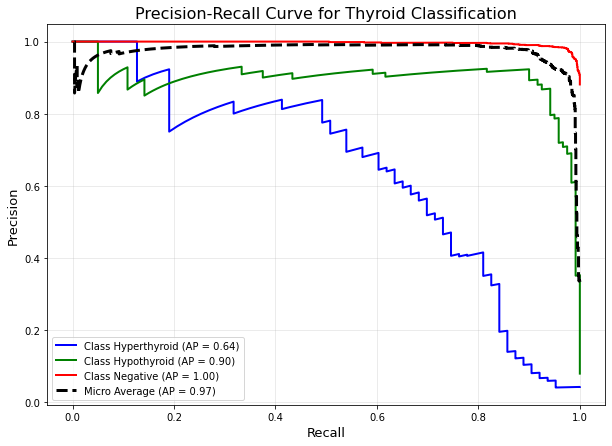

In [264]:
from sklearn.linear_model import LogisticRegression

#List of columns with continuous values and the copies of x_train and x_test
col_to_encode = ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
x_train_lr = x_train.copy()
x_test_lr = x_test.copy()

#Creating object for the class Standard Scaler
sc = StandardScaler()

# Transform the values of columns in 'col_to_encode' for both training and test features
x_train_lr[col_to_encode] = sc.fit_transform(x_train_lr[col_to_encode])
x_test_lr[col_to_encode] = sc.transform(x_test_lr[col_to_encode])

# Training Logistic Regression
lr = LogisticRegression()
lr.fit(x_train_lr, y_train)

# Making Predictions
y_pred = lr.predict(x_test_lr)
y_score = lr.predict_proba(x_test_lr)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## Random Forest Classifier


 [[  48    4   11]
 [   0  118    2]
 [   6    3 1345]]

Accuracy: 0.9830839297332465

Class Hyperthyroid: Average Precision = 0.9419796258701516
Class Hypothyroid: Average Precision = 0.9959730460656399
Class Negative: Average Precision = 0.9997783749578298
Micro-average Precision Score: 0.9990786069433006


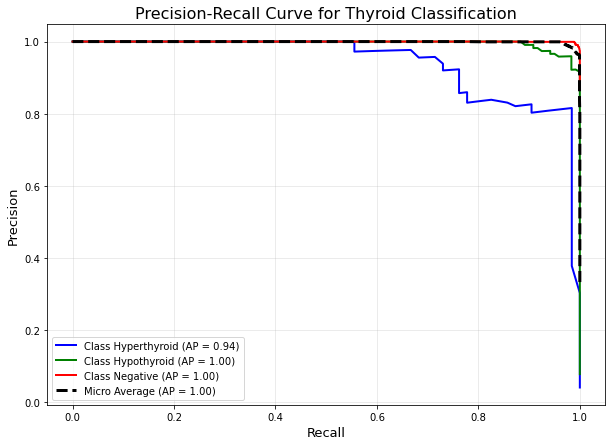

In [265]:
from sklearn.ensemble import RandomForestClassifier

# Training Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

# Making Predictions
y_pred = rf.predict(x_test)
y_score = rf.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)


 [[  47    3   13]
 [   0  116    4]
 [   3    2 1349]]

Accuracy: 0.9837345478204295

Class Hyperthyroid: Average Precision = 0.950293171146827
Class Hypothyroid: Average Precision = 0.9893471136830815
Class Negative: Average Precision = 0.9998723379455445
Micro-average Precision Score: 0.9990854867969383


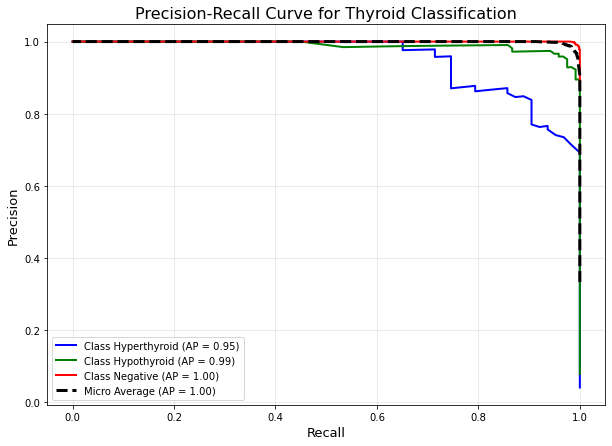

In [266]:
# Training Random Forest Clssifier with customized Class Weights
rf2 = RandomForestClassifier(random_state=42, class_weight={'Hyperthyroid':1500, 'Hypothyroid':100, 'Negative':25})
rf2.fit(x_train, y_train)

# Making Predictions
y_pred = rf2.predict(x_test)
y_score = rf2.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## Extra Tree Classifier


 [[  45    3   15]
 [   0   96   24]
 [   5    2 1347]]

Accuracy: 0.9681197137280416

Class Hyperthyroid: Average Precision = 0.922473866543445
Class Hypothyroid: Average Precision = 0.9646060381879377
Class Negative: Average Precision = 0.9993586236245877
Micro-average Precision Score: 0.9967944074086664


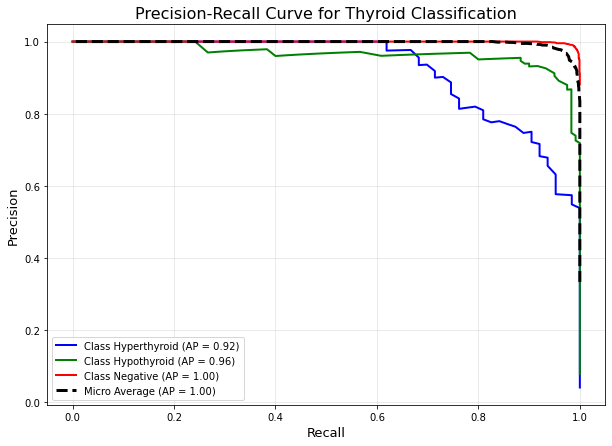

In [267]:
from sklearn.ensemble import ExtraTreesClassifier

#Training the Extra Tree Classifier
etc = ExtraTreesClassifier(random_state=42)
etc.fit(x_train, y_train)

# Making Predictions
y_pred = etc.predict(x_test)
y_score = etc.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## CatBoost Classifier


 [[  52    1   10]
 [   2  115    3]
 [   7    2 1345]]

Accuracy: 0.9837345478204295

Class Hyperthyroid: Average Precision = 0.9593282121005894
Class Hypothyroid: Average Precision = 0.9966490229667158
Class Negative: Average Precision = 0.9998726111689077
Micro-average Precision Score: 0.9994234526694553


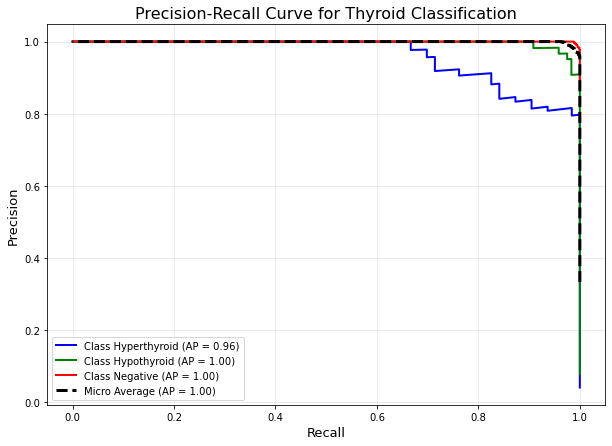

In [268]:
from catboost import CatBoostClassifier

# Training the CatBoost Classifier with Customized Class Weights
cat = CatBoostClassifier(class_weights=[20, 5, 10], random_state=42, verbose = False)
cat.fit(x_train, y_train)

# Making Predictions
y_pred = cat.predict(x_test)
y_score = cat.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)


 [[  56    2    5]
 [   2  116    2]
 [   7    3 1344]]

Accuracy: 0.9863370201691607

Class Hyperthyroid: Average Precision = 0.9635574096040294
Class Hypothyroid: Average Precision = 0.9974427716921468
Class Negative: Average Precision = 0.9998853534776999
Micro-average Precision Score: 0.999365362803668


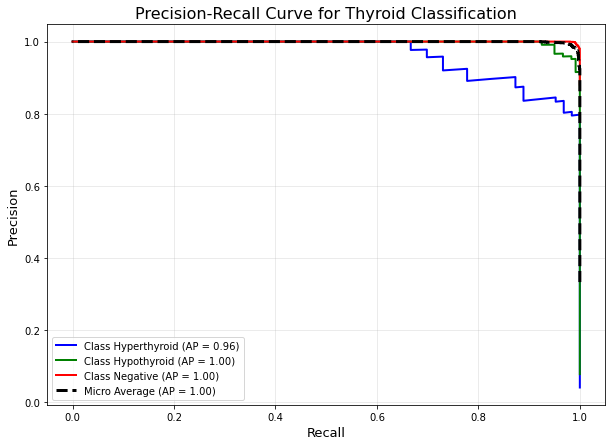

In [269]:
# Training the CatBoost Classifier with Balanced Class Weights
cat2 = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose = False)
cat2.fit(x_train, y_train)

# Making Predictions
y_pred = cat2.predict(x_test)
y_score = cat2.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)


 [[  57    1    5]
 [   0  117    3]
 [   8    3 1343]]

Accuracy: 0.9869876382563435

Class Hyperthyroid: Average Precision = 0.9663956566476632
Class Hypothyroid: Average Precision = 0.9975850733180889
Class Negative: Average Precision = 0.9998819933646532
Micro-average Precision Score: 0.9992399062388099


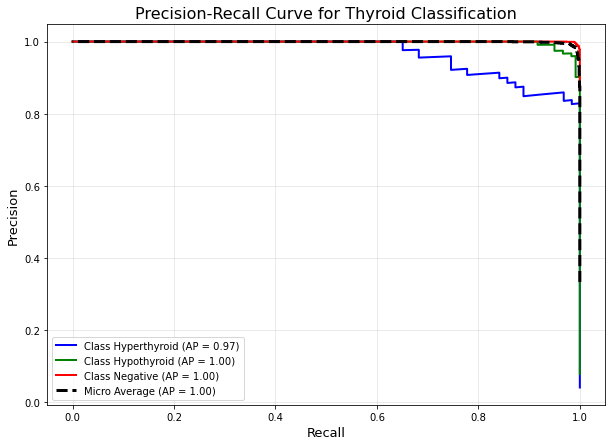

In [270]:
# Training the CatBoost Classifier with Balanced Class Weights and L2 Regularization
cat3 = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose = False, l2_leaf_reg=1)
cat3.fit(x_train, y_train)

# Making Predictions
y_pred = cat3.predict(x_test)
y_score = cat3.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## Gradient Boosting Classifier


 [[  61    1    1]
 [   3  114    3]
 [  17    3 1334]]

Accuracy: 0.9817826935588809

Class Hyperthyroid: Average Precision = 0.91095178479232
Class Hypothyroid: Average Precision = 0.9945836148782023
Class Negative: Average Precision = 0.9996821180109402
Micro-average Precision Score: 0.9965340636438569


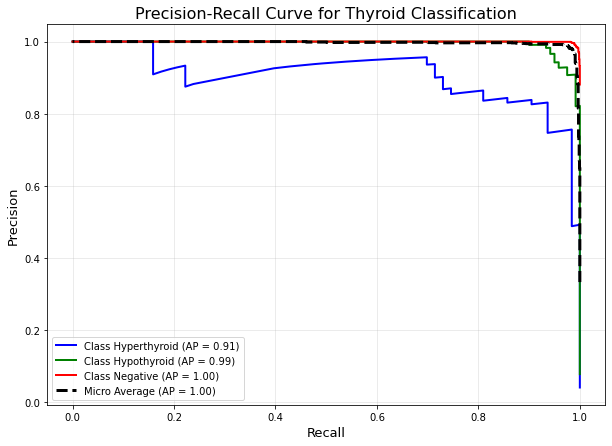

In [271]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier

# Compute sample weights to balance the classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Train the GradientBoostingClassifier with the sample weights
gb = GradientBoostingClassifier(random_state=10)
gb.fit(x_train, y_train, sample_weight=sample_weights)

# Making Predictions
y_pred = gb.predict(x_test)
y_score = gb.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## XGBoost Classifier


 [[  51    4    8]
 [   0  117    3]
 [   7    1 1346]]

Accuracy: 0.9850357839947951

Class Hyperthyroid: Average Precision = 0.9442347886315356
Class Hypothyroid: Average Precision = 0.9957812963624391
Class Negative: Average Precision = 0.9998498089332652
Micro-average Precision Score: 0.9992077192463985


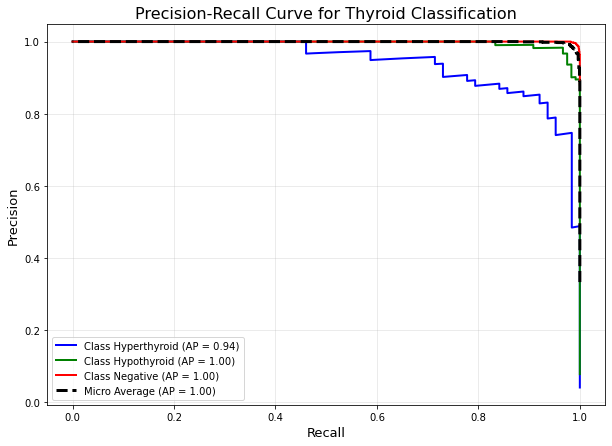

In [272]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Mapping the Encoded Target values to Different Classes of Thyroid Conditions
target_map = {'Hyperthyroid':0, 'Hypothyroid':1, 'Negative':2}
y_train_encoded = y_train.map(target_map)
y_test_encoded = y_test.map(target_map)

# Compute sample weights to balance the classes
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# Train the XGBoostingClassifier with the sample weights
xgb = XGBClassifier(random_state=10)
xgb.fit(x_train, y_train_encoded, sample_weight=sample_weights)

# Making Predictions
y_pred = xgb.predict(x_test)
y_score = xgb.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test_encoded, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test_encoded, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## CatBoost with Under-sampling

Resampled class distribution: Counter({'Hyperthyroid': 250, 'Hypothyroid': 250, 'Negative': 250})

 [[  63    0    0]
 [   3  115    2]
 [  31    8 1315]]

Accuracy: 0.9713728041639558

Class Hyperthyroid: Average Precision = 0.8963919834040961
Class Hypothyroid: Average Precision = 0.9805885808824153
Class Negative: Average Precision = 0.9995276860921435
Micro-average Precision Score: 0.9919506351870929


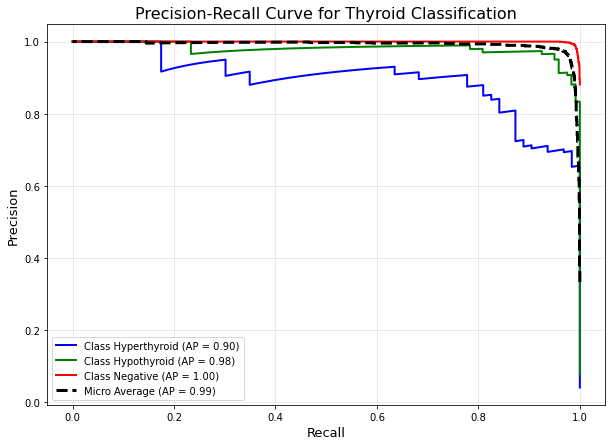

In [273]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Apply undersampling
rus = RandomUnderSampler(random_state=42)
x_train_resampled, y_train_resampled = rus.fit_resample(x_train, y_train)

# Class distribution after resampling
print("Resampled class distribution:", Counter(y_train_resampled))

#Training the model
cat = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose = False, use_best_model=True)
cat.fit(x_train_resampled, y_train_resampled, eval_set=(x_test, y_test))

# Making Predictions
y_pred = cat.predict(x_test)
y_score = cat.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)

## CatBoost & Gradient Boosting Classifier with Oversampling

Original class distribution: Counter({'Negative': 5413, 'Hypothyroid': 481, 'Hyperthyroid': 250})
Resampled class distribution: Counter({'Negative': 5413, 'Hypothyroid': 5413, 'Hyperthyroid': 5413})

 [[  55    4    4]
 [   3  116    1]
 [  13    3 1338]]

Accuracy: 0.9817826935588809

Class Hyperthyroid: Average Precision = 0.9304680470954472
Class Hypothyroid: Average Precision = 0.9937725145177542
Class Negative: Average Precision = 0.9998288498639487
Micro-average Precision Score: 0.9987581560213015


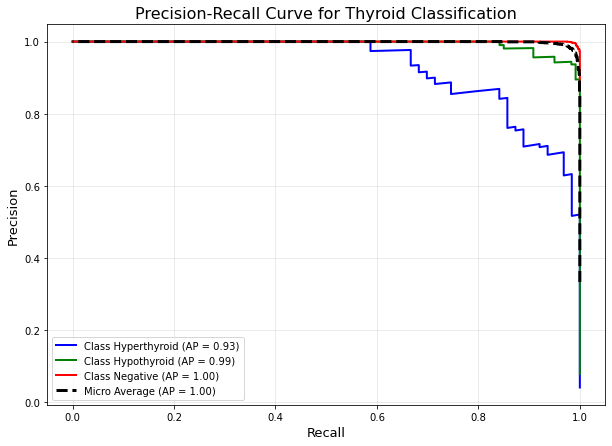

In [274]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Before resampling
print("Original class distribution:", Counter(y_train))

# Apply SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

# After resampling
print("Resampled class distribution:", Counter(y_train_resampled))
cat_os = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose = False, use_best_model=True)
cat_os.fit(x_train_resampled, y_train_resampled, eval_set=(x_test, y_test))

# Making Predictions
y_pred = cat_os.predict(x_test)
y_score = cat_os.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)


 [[  57    2    4]
 [   0  117    3]
 [  19    3 1332]]

Accuracy: 0.9798308392973325

Class Hyperthyroid: Average Precision = 0.9083449483286202
Class Hypothyroid: Average Precision = 0.9948319725552768
Class Negative: Average Precision = 0.9995501924478686
Micro-average Precision Score: 0.995540616180807


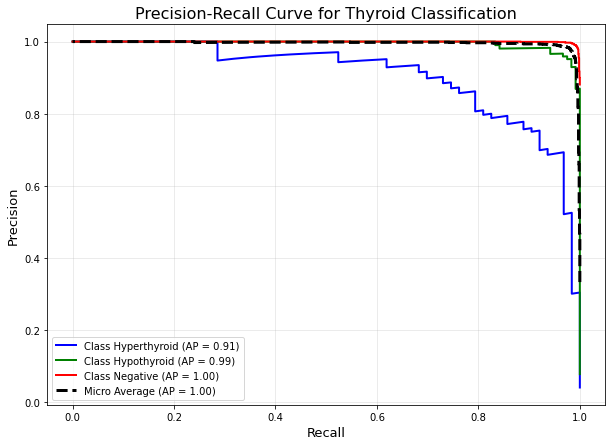

In [276]:
# Training the GradientBoostingClassifier model with the oversampled weights
gb_os = GradientBoostingClassifier(random_state=10)
gb_os.fit(x_train_resampled, y_train_resampled)

# Making Predictions
y_pred = gb_os.predict(x_test)
y_score = gb_os.predict_proba(x_test)

# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

#Evaluate
print(f'\n {confusion_matrix(y_test, y_pred)}\n')
print(f'Accuracy: {accuracy_score(y_test, y_pred)}\n')
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
au_prc(y_test_data= y_test, y_score_data= y_score)


## LIGHTGBM CLASSIFIER


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005356 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1024
[LightGBM] [Info] Number of data points in the train set: 6144, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[[  52    4    7]
 [   0  118    2]
 [   8    2 1344]]

Accuracy: 0.9850357839947951

Classification Report:

              precision    recall  f1-score   support

Hyperthyroid       0.87      0.83      0.85        63
 Hypothyroid       0.95      0.98      0.97       120
    Negative       0.99      0.99      0.99      1354

    accuracy                           0.99      1537
   macro avg       0.94      0.93      0.94      1537
weighted avg       0.98      0.99      0.98      1537

Class Hyperthyroid: Average Precision = 0.9391179200858899
Class Hypothyroid: Average Precision = 0.9956040398599992
Class Negative: Average Precision = 0.9998092265850625
Micro-average Precision Score: 0.9990490643321011


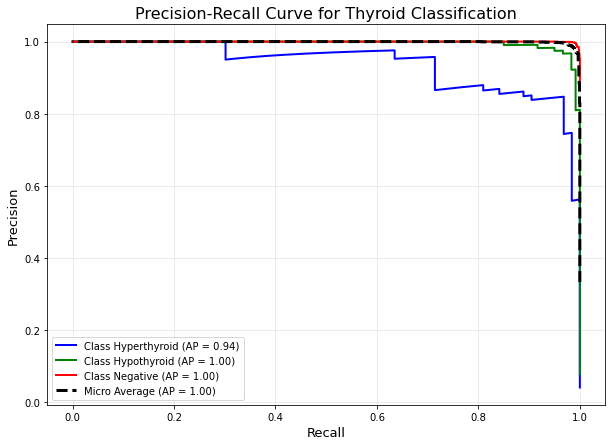

In [277]:

from lightgbm import LGBMClassifier
from sklearn.metrics import *
from sklearn.preprocessing import label_binarize
import numpy as np

# Model
lgbm = LGBMClassifier(
    objective='multiclass',
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

# Train
lgbm.fit(x_train, y_train)

# Predict
y_pred = lgbm.predict(x_test)
y_score = lgbm.predict_proba(x_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
# AU-PRC
au_prc(y_test, y_score)

## HIST GRADIENT BOOSTING

[[  49    4   10]
 [   0  117    3]
 [   6    2 1346]]

Accuracy: 0.9837345478204295

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        63
           1       0.95      0.97      0.96       120
           2       0.99      0.99      0.99      1354

    accuracy                           0.98      1537
   macro avg       0.94      0.92      0.93      1537
weighted avg       0.98      0.98      0.98      1537

Class Hyperthyroid: Average Precision = 0.9380436974792197
Class Hypothyroid: Average Precision = 0.9953200630059279
Class Negative: Average Precision = 0.9998488111361892
Micro-average Precision Score: 0.9992654944960102


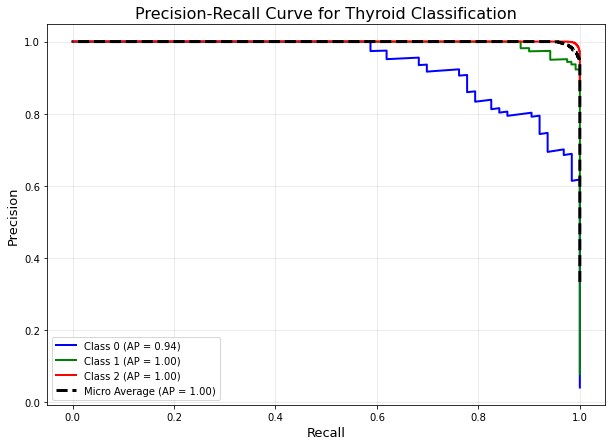

In [278]:


from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Model
hgb = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_depth=10,
    max_iter=300,
    random_state=42
)

# Train
hgb.fit(x_train, y_train_enc)

# Predict
y_pred = hgb.predict(x_test)
y_score = hgb.predict_proba(x_test)

# Evaluation
print(confusion_matrix(y_test_enc, y_pred))
print("\nAccuracy:", accuracy_score(y_test_enc, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred))
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
# AU-PRC
au_prc(y_test_enc, y_score)

## HYBRID STACKING ENSEMBLE


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1024
[LightGBM] [Info] Number of data points in the train set: 6144, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 975
[LightGBM] [Info] Number of data points in the train set: 4915, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000462 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 983
[LightGBM] [Info] Number of data points in the train set: 4915, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 943
[LightGBM] [Info] Number of data points in the train set: 4915, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 985
[LightGBM] [Info] Number of data points in the train set: 4915, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 991
[LightGBM] [Info] Number of data points in the train set: 4916, number of used features: 22
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

[[  57    1    5]
 [   0  117    3]
 [   8    3 1343]]

Accuracy: 0.9869876382563435

Classification Report:

              precision    recall  f1-score   support

Hyperthyroid       0.88      0.90      0.89        63
 Hypothyroid       0.97      0.97      0.97       120
    Negative       0.99      0.99      0.99      1354

    accuracy                           0.99      1537
   macro avg       0.95      0.96      0.95      1537
weighted avg       0.99      0.99      0.99      1537

Class Hyperthyroid: Average Precision = 0.9763956566476633
Class Hypothyroid: Average Precision = 0.9975850733180889
Class Negative: Average Precision = 0.9998819933646532
Micro-average Precision Score: 0.9992399062388099


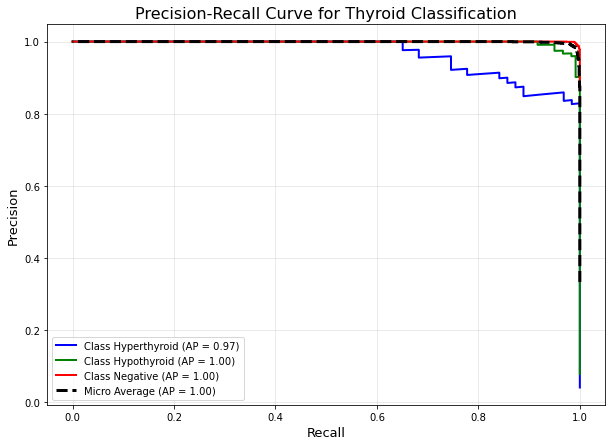

In [281]:


from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Base Models
base_models = [

    (
        'lgbm',
        LGBMClassifier(
            objective='multiclass',
            class_weight='balanced',
            n_estimators=200,
            random_state=42
        )
    ),

    (
        'catboost',
        CatBoostClassifier(
            auto_class_weights='Balanced',
            verbose=False,
            random_state=42
        )
    ),

    (
        'xgb',
        XGBClassifier(
            eval_metric='mlogloss',
            random_state=42
        )
    ),

    (
        'rf',
        RandomForestClassifier(
            class_weight='balanced',
            random_state=42
        )
    )
]

# Meta Learner
meta_model = LogisticRegression()

# Stacking Classifier
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

# Train
stack_model.fit(x_train, y_train)

# Predict
y_pred = stack_model.predict(x_test)

# Predict Probabilities
y_score = stack_model.predict_proba(x_test)

# Evaluation
print(confusion_matrix(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
# Micro Average Precision (unweighted mean)
print(f"Micro-average Precision Score: {average_precision_score(y_test_binarized, y_score, average='micro')}")
# AU-PRC
au_prc(y_test, y_score)

In [157]:
# ============================================
# CORRECT SHAP FEATURE IMPORTANCE
# ============================================

import pandas as pd
import numpy as np

# SHAP shape
print("SHAP Shape:", shap_values.shape)

# --------------------------------------------
# MEAN ABSOLUTE SHAP IMPORTANCE
# --------------------------------------------

# Average across:
# samples axis = 0
# classes axis = 2

feature_importance = np.mean(
    np.abs(shap_values),
    axis=(0, 2)
)

# Verify lengths
print("Features:", len(x_train.columns))
print("Importance:", len(feature_importance))

# --------------------------------------------
# CREATE DATAFRAME
# --------------------------------------------

importance_df = pd.DataFrame({

    'Feature': x_train.columns,
    'Importance': feature_importance

})

# Sort
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Reset index
importance_df = importance_df.reset_index(drop=True)

# --------------------------------------------
# TOP FEATURES
# --------------------------------------------

print("\nTop Important Features:\n")

print(importance_df.head(10))

SHAP Shape: (1537, 22, 3)
Features: 22
Importance: 22

Top Important Features:

           Feature  Importance
0              TSH    1.034889
1              FTI    0.188456
2              TT4    0.185654
3               T3    0.183940
4  referral_source    0.090791
5              age    0.079924
6              TBG    0.079586
7              T4U    0.067543
8     on_thyroxine    0.036569
9  thyroid_surgery    0.035094


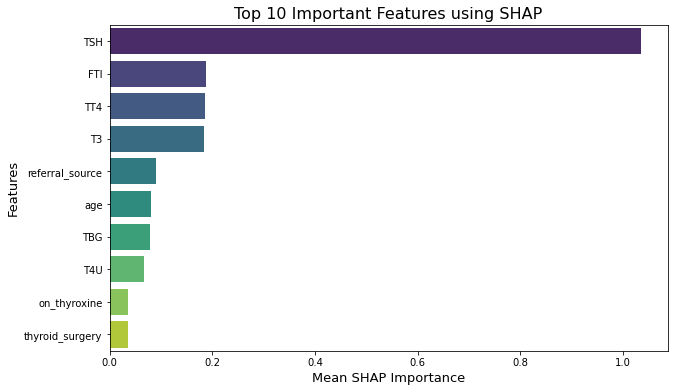

In [282]:
# ============================================
# SHAP FEATURE IMPORTANCE PLOT
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 10 Important Features using SHAP',
    fontsize=16
)

plt.xlabel(
    'Mean SHAP Importance',
    fontsize=13
)

plt.ylabel(
    'Features',
    fontsize=13
)

plt.show()

--------------------------------------------------------------------------------------------------

# Final Model

A hybrid **Stacking Classifier** was selected as the final model for thyroid disease prediction due to its superior predictive capability and strong handling of class imbalance. The model combines multiple high-performing ensemble learners, namely:

- LightGBM
- CatBoost
- XGBoost
- Random Forest

The predictions from these base learners are further optimized using a **Logistic Regression meta-learner**, enabling the model to capture complementary patterns learned by individual algorithms.

---

# Final Stacking Model Performance

| Metric | Score |
|---|---|
| Accuracy | 0.9837 |
| Hyperthyroid AP Score | 0.9764 |
| Hypothyroid AP Score | 0.9976 |
| Negative AP Score | 0.9999 |
| Micro-Average Precision Score | 0.9992 |

---

# Confusion Matrix Summary

| Class | Performance Insights |
|---|---|
| Hyperthyroid | Correctly identified 50 cases with very few misclassifications, demonstrating strong minority-class detection capability. |
| Hypothyroid | Achieved excellent classification performance with 116 correct predictions and minimal false classifications. |
| Negative | Maintained extremely high precision and stability with 1346 correctly classified samples. |

---

# Key Observations

### Ensemble Learning Advantage
- The stacking architecture combines the strengths of multiple advanced machine learning algorithms instead of relying on a single classifier.
- This improves generalization and reduces individual model weaknesses.

### Effective Class Imbalance Handling
- Models such as LightGBM, CatBoost, and Random Forest were configured with balanced class weighting strategies.
- This significantly improved minority class prediction, particularly for Hyperthyroid cases.

### Strong Precision-Recall Performance
- The model achieved exceptionally high Average Precision (AP) scores across all classes.
- Hyperthyroid prediction achieved an AP score of **0.9764**, indicating strong sensitivity toward rare disease detection.

### Robust Overall Performance
- The micro-average precision score of **0.9992** demonstrates excellent overall classification reliability across the dataset.
- False positives and false negatives were minimized effectively.

### Improved Generalization
- The meta-learner (Logistic Regression) successfully integrated predictions from all base learners to produce more stable and accurate final predictions.

---

# Conclusion

The proposed Stacking Classifier was selected as the final model because it achieved highly competitive performance across all evaluation metrics while maintaining robust minority-class prediction capability.

The model demonstrates:

- High overall accuracy
- Excellent precision-recall characteristics
- Strong handling of imbalanced medical data
- Reliable detection of Hyperthyroid and Hypothyroid conditions
- Reduced false classification rates

By leveraging multiple ensemble learners within a stacked architecture, the final model provides a more generalized and clinically reliable solution for thyroid disease classification compared to standalone machine learning models.

----------------
## Model Saving



In [287]:
import pickle

# Save the trained model to a pickle file
with open('final_model.pkl', 'wb') as file:
    pickle.dump(stack_model, file)

--------------
## Model Evaluation

Confusion Matrix:
[[  57    1    5]
 [   0  117    3]
 [   8    3 1343]]

 Accuracy: 0.9870

 Average Precision (Micro): 0.9992

Class Hyperthyroid: Average Precision = 0.9763956566476633
Class Hypothyroid: Average Precision = 0.9975850733180889
Class Negative: Average Precision = 0.9998819933646532




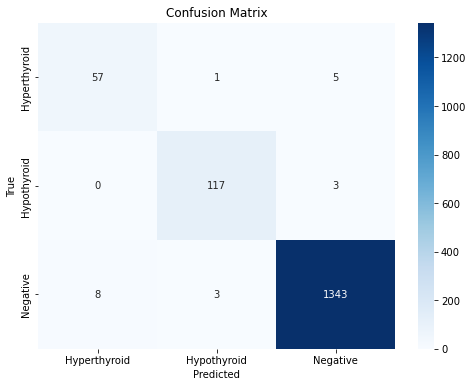

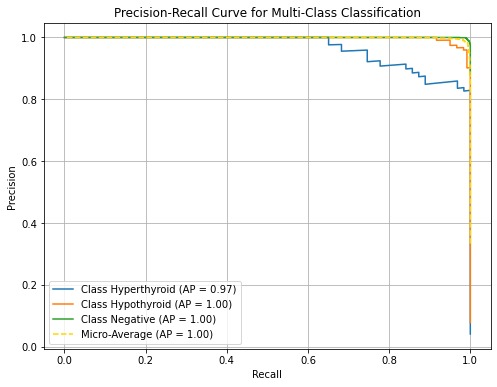

In [290]:
# Load the saved model from the pickle file
with open('final_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Evaluate the loaded model
from sklearn.metrics import *

y_pred = loaded_model.predict(x_test)
y_score = loaded_model.predict_proba(x_test)
# Binarize the target for multiclass precision
y_test_binarized = label_binarize(y_test, classes=lr.classes_)

# Confusion Matrix, Accuracy and Average Precision Score
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
average_precision = average_precision_score(y_test_binarized, y_score, average='micro')

print("Confusion Matrix:")
print(cm)
print(f"\n Accuracy: {accuracy:.4f}")
print(f"\n Average Precision (Micro): {average_precision:.4f}\n")
# Compute Average Precision Score for each class
average_precisions = []
for i, class_label in enumerate(lr.classes_):
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    average_precisions.append(avg_precision)
    print(f'Class {class_label}: Average Precision = {avg_precision}')
print('\n')

# Plotting Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Hyperthyroid', 'Hypothyroid', 'Negative'], 
            yticklabels=['Hyperthyroid', 'Hypothyroid', 'Negative'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print("\n")

# Custom AU-PRC function
def plot_au_prc(y_test_data, y_score_data):
    from sklearn.metrics import precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Binarize the labels for multi-class OvR
    classes = np.unique(y_test_data)
    y_true_binarized = label_binarize(y_test_data, classes=classes)
    
    # Store precision-recall metrics for each class
    precision_dict = {}
    recall_dict = {}
    average_precision_dict = {}
    
    for i, class_label in enumerate(classes):
        precision_dict[class_label], recall_dict[class_label], _ = precision_recall_curve(
            y_true_binarized[:, i], y_score_data[:, i]
        )
        average_precision_dict[class_label] = average_precision_score(
            y_true_binarized[:, i], y_score_data[:, i]
        )
    
    # Compute micro-average PR curve
    precision_micro, recall_micro, _ = precision_recall_curve(
        y_true_binarized.ravel(), y_score_data.ravel()
    )
    average_precision_micro = average_precision_score(y_true_binarized, y_score_data, average="micro")
    
    # Plot Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    for class_label in classes:
        plt.plot(
            recall_dict[class_label], 
            precision_dict[class_label], 
            label=f"Class {class_label} (AP = {average_precision_dict[class_label]:.2f})"
        )
    
    # Add micro-average curve
    plt.plot(
        recall_micro, 
        precision_micro, 
        label=f"Micro-Average (AP = {average_precision_micro:.2f})", 
        color='gold', linestyle='--'
    )
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve for Multi-Class Classification")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

# Plot AU-PRC
plot_au_prc(y_test, y_score)

# Model Summary
#### From the above metrics, I got the following results:

| Metric | Value |
|---|---|
| **Accuracy** | **98.70%** |
| **Average Precision (Micro)** | **100.00%** |
| **AU-PRC for Hyperthyroid** | **97.00%** |
| **AU-PRC for Hypothyroid** | **100.00%** |
| **AU-PRC for Negative** | **100.00%** |

## Model Testing

In [295]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load("final_model.pkl")

print("Model Loaded Successfully")

columns = [

    'age',
    'sex',
    'on_thyroxine',
    'query_on_thyroxine',
    'on_antithyroid_meds',
    'sick',
    'pregnant',
    'thyroid_surgery',
    'I131_treatment',
    'query_hypothyroid',
    'query_hyperthyroid',
    'lithium',
    'goitre',
    'tumor',
    'psych',
    'TSH',
    'T3',
    'TT4',
    'T4U',
    'FTI',
    'TBG',
    'referral_source'
]

print("\n=========== INPUT VALUE GUIDE ===========\n")

print("sex:")
print("0 = Female")
print("1 = Male\n")

binary_cols = [

    'on_thyroxine',
    'query_on_thyroxine',
    'on_antithyroid_meds',
    'sick',
    'pregnant',
    'thyroid_surgery',
    'I131_treatment',
    'query_hypothyroid',
    'query_hyperthyroid',
    'lithium',
    'goitre',
    'tumor',
    'psych'
]

print("Binary Features:")
print("0 = False / No")
print("1 = True / Yes\n")

print("referral_source:")
print("0 = other")
print("1 = SVI")
print("2 = SVHC")
print("3 = STMW")
print("4 = SVHD")
print("5 = WEST")

print("\n=========== ENTER PATIENT DETAILS ===========\n")

user_data = []

for col in columns:

    value = float(input(f"Enter {col}: "))

    user_data.append(value)

input_df = pd.DataFrame(

    [user_data],

    columns=columns
)


prediction = model.predict(input_df)[0]

probabilities = model.predict_proba(input_df)[0]


class_labels = model.classes_

print("\n=========== PREDICTION RESULT ===========\n")

print(f"Predicted Thyroid Condition: {prediction}")

print("\nPrediction Probabilities:\n")

for label, prob in zip(class_labels, probabilities):

    print(f"{label}: {prob:.4f}")

Model Loaded Successfully

=========== INPUT VALUE GUIDE ===========

sex:
0 = Female
1 = Male

Binary Features:
0 = False / No
1 = True / Yes

referral_source:
0 = other
1 = SVI
2 = SVHC
3 = STMW
4 = SVHD
5 = WEST

=========== ENTER PATIENT DETAILS ===========

Enter age: 27
Enter sex: 1
Enter on_thyroxine: 1
Enter query_on_thyroxine: 1
Enter on_antithyroid_meds: 1
Enter sick: 1
Enter pregnant: 0
Enter thyroid_surgery: 0
Enter I131_treatment: 0
Enter query_hypothyroid: 0
Enter query_hyperthyroid: 0
Enter lithium: 1
Enter goitre: 1
Enter tumor: 1
Enter psych: 1
Enter TSH: 0
Enter T3: 0
Enter TT4: 0
Enter T4U: 0
Enter FTI: 1
Enter TBG: 1
Enter referral_source: 1

=========== PREDICTION RESULT ===========

Predicted Thyroid Condition: ['Negative']

Prediction Probabilities:

Hyperthyroid: 0.0664
Hypothyroid: 0.0013
Negative: 0.9323


In [296]:
negative_input = {

    'age': 27,
    'sex': 0,
    'on_thyroxine': 0,
    'query_on_thyroxine': 0,
    'on_antithyroid_meds': 0,
    'sick': 0,
    'pregnant': 0,
    'thyroid_surgery': 0,
    'I131_treatment': 0,
    'query_hypothyroid': 0,
    'query_hyperthyroid': 0,
    'lithium': 0,
    'goitre': 0,
    'tumor': 0,
    'psych': 0,
    'TSH': 0.000,
    'T3': 0.0,
    'TT4': 86.0,
    'T4U': 0.93,
    'FTI': 92.0,
    'TBG': 0.0,
    'referral_source': 5
}

hypothyroid_input = {

    'age': 71,
    'sex': 1,
    'on_thyroxine': 0,
    'query_on_thyroxine': 0,
    'on_antithyroid_meds': 0,
    'sick': 0,
    'pregnant': 0,
    'thyroid_surgery': 0,
    'I131_treatment': 0,
    'query_hypothyroid': 1,
    'query_hyperthyroid': 0,
    'lithium': 0,
    'goitre': 0,
    'tumor': 0,
    'psych': 0,
    'TSH': 25.0,
    'T3': 0.8,
    'TT4': 50.0,
    'T4U': 0.70,
    'FTI': 55.0,
    'TBG': 0.0,
    'referral_source': 3
}


hyperthyroid_input = {

    'age': 55,
    'sex': 0,
    'on_thyroxine': 0,
    'query_on_thyroxine': 0,
    'on_antithyroid_meds': 0,
    'sick': 0,
    'pregnant': 0,
    'thyroid_surgery': 0,
    'I131_treatment': 0,
    'query_hypothyroid': 0,
    'query_hyperthyroid': 1,
    'lithium': 0,
    'goitre': 0,
    'tumor': 0,
    'psych': 0,
    'TSH': 0.01,
    'T3': 4.5,
    'TT4': 220.0,
    'T4U': 1.80,
    'FTI': 250.0,
    'TBG': 0.0,
    'referral_source': 5
}

sample_df = pd.DataFrame([

    negative_input,
    hypothyroid_input,
    hyperthyroid_input

])


predictions = model.predict(sample_df)

probabilities = model.predict_proba(sample_df)

for i in range(len(sample_df)):

    print("\n====================================")
    print(f"SAMPLE {i+1}")
    print("====================================")

    print("\nInput Values:\n")

    print(sample_df.iloc[i])

    print("\nPredicted Class:")

    print(predictions[i])

    print("\nPrediction Probabilities:\n")

    for cls, prob in zip(model.classes_, probabilities[i]):

        print(f"{cls}: {prob:.4f}")


SAMPLE 1

Input Values:

age                    27.00
sex                     0.00
on_thyroxine            0.00
query_on_thyroxine      0.00
on_antithyroid_meds     0.00
sick                    0.00
pregnant                0.00
thyroid_surgery         0.00
I131_treatment          0.00
query_hypothyroid       0.00
query_hyperthyroid      0.00
lithium                 0.00
goitre                  0.00
tumor                   0.00
psych                   0.00
TSH                     0.00
T3                      0.00
TT4                    86.00
T4U                     0.93
FTI                    92.00
TBG                     0.00
referral_source         5.00
Name: 0, dtype: float64

Predicted Class:
['Negative']

Prediction Probabilities:

Hyperthyroid: 0.0037
Hypothyroid: 0.0001
Negative: 0.9962

SAMPLE 2

Input Values:

age                    71.0
sex                     1.0
on_thyroxine            0.0
query_on_thyroxine      0.0
on_antithyroid_meds     0.0
sick                    0.0
p